In [6]:
### Query all the dbs in /datasets directory for their schema. 

### Query all of them for how many rows of theirs have len between 10 and 150 lines, and how many 
### are vulnerable (non empty vuln column) and how many are not in this range. 

### for the Juliet dbs (prefix of juliet), return these counts grouped by CWE. to get this look at the grp column and count 
## for distinct CWE values. 

In [7]:
# List all .db files in the datasets directory and print their schema
import os
import sqlite3
import pandas as pd

db_dir = 'datasets'
db_files = [f for f in os.listdir(db_dir) if f.endswith('.db')]
print('Found DB files:', db_files)

schemas = {}
for db_file in db_files:
    db_path = os.path.join(db_dir, db_file)
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    print(f'\nSchema for {db_file}:')
    for table in tables:
        table_name = table[0]
        cursor.execute(f'PRAGMA table_info({table_name});')
        columns = cursor.fetchall()
        print(f'  Table: {table_name}')
        for col in columns:
            print(f'    {col}')
    conn.close()

Found DB files: ['juliet_csharp.db', 'bugsinpy.db', 'juliet_c.db', 'devign.db', 'juliet_java.db']

Schema for juliet_csharp.db:
  Table: funcs
    (0, 'grp', 'TEXT', 0, None, 0)
    (1, 'id', 'TEXT', 0, None, 0)
    (2, 'start', 'INT', 0, None, 0)
    (3, 'end', 'INT', 0, None, 0)
    (4, 'vuln', 'TEXT', 0, None, 0)
    (5, 'code', 'TEXT', 0, None, 0)
    (6, 'len', 'INT', 0, None, 0)

Schema for bugsinpy.db:
  Table: funcs
    (0, 'grp', 'TEXT', 0, None, 0)
    (1, 'id', 'TEXT', 0, None, 0)
    (2, 'start', 'INT', 0, None, 0)
    (3, 'end', 'INT', 0, None, 0)
    (4, 'vuln', 'TEXT', 0, None, 0)
    (5, 'code', 'TEXT', 0, None, 0)
    (6, 'len', 'INT', 0, None, 0)

Schema for juliet_c.db:
  Table: funcs
    (0, 'grp', 'TEXT', 0, None, 0)
    (1, 'id', 'TEXT', 0, None, 0)
    (2, 'start', 'INT', 0, None, 0)
    (3, 'end', 'INT', 0, None, 0)
    (4, 'vuln', 'TEXT', 0, None, 0)
    (5, 'code', 'TEXT', 0, None, 0)
    (6, 'len', 'INT', 0, None, 0)

Schema for devign.db:
  Table: funcs
    

juliet_csharp.db: Total=98135, Vulnerable=83150, Non-vulnerable=14985
  Top CWEs (vulnerable):
 grp
CWE190    11467
CWE197     9870
CWE129     8642
CWE191     7903
CWE369     4854
dtype: int64
bugsinpy.db: Total=20794, Vulnerable=20794, Non-vulnerable=0
bugsinpy.db: Total=20794, Vulnerable=20794, Non-vulnerable=0
juliet_c.db: Total=278075, Vulnerable=171280, Non-vulnerable=106795
  Top CWEs (vulnerable):
 grp
CWE122    16092
CWE121    13387
CWE190    11777
CWE78     11520
CWE134    11286
dtype: int64
devign.db: Total=20341, Vulnerable=20341, Non-vulnerable=0
juliet_c.db: Total=278075, Vulnerable=171280, Non-vulnerable=106795
  Top CWEs (vulnerable):
 grp
CWE122    16092
CWE121    13387
CWE190    11777
CWE78     11520
CWE134    11286
dtype: int64
devign.db: Total=20341, Vulnerable=20341, Non-vulnerable=0
juliet_java.db: Total=120192, Vulnerable=98787, Non-vulnerable=21405
  Top CWEs (vulnerable):
 grp
CWE190    16451
CWE191    13289
CWE129    11130
CWE89      9261
CWE369     5924
dtype:

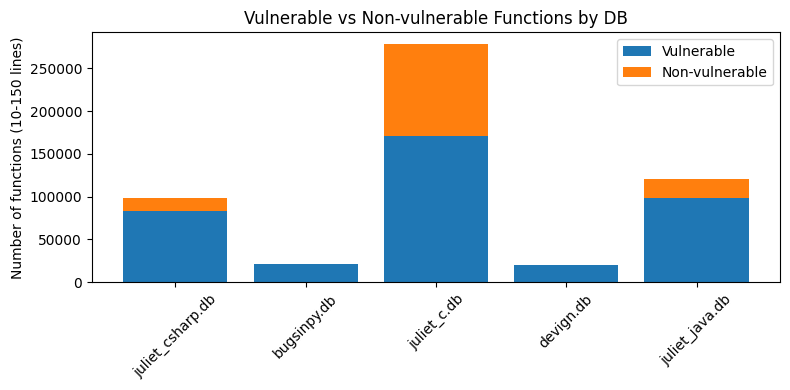

In [8]:
# Count stats for each DB: functions with 10-150 lines, vulnerable/non-vulnerable, Juliet grouped by CWE
import matplotlib.pyplot as plt

stats = {}
for db_file in db_files:
    db_path = os.path.join(db_dir, db_file)
    conn = sqlite3.connect(db_path)
    query = "SELECT grp, id, start, end, vuln, len FROM funcs WHERE len BETWEEN 10 AND 150"
    df = pd.read_sql_query(query, conn)
    total = len(df)
    vuln = df['vuln'].notnull() & (df['vuln'] != '')
    vuln_count = vuln.sum()
    non_vuln_count = total - vuln_count
    stats[db_file] = {'total': total, 'vulnerable': vuln_count, 'non_vulnerable': non_vuln_count}
    print(f"{db_file}: Total={total}, Vulnerable={vuln_count}, Non-vulnerable={non_vuln_count}")
    # Juliet DBs: group by CWE
    if db_file.startswith('juliet'):
        cwe_counts = df[vuln].groupby('grp').size().sort_values(ascending=False)
        print(f"  Top CWEs (vulnerable):\n", cwe_counts.head())
        stats[db_file]['cwe_counts'] = cwe_counts
    conn.close()

# Plot summary for all DBs
labels = list(stats.keys())
vuln_vals = [stats[k]['vulnerable'] for k in labels]
non_vuln_vals = [stats[k]['non_vulnerable'] for k in labels]

plt.figure(figsize=(8,4))
plt.bar(labels, vuln_vals, label='Vulnerable')
plt.bar(labels, non_vuln_vals, bottom=vuln_vals, label='Non-vulnerable')
plt.ylabel('Number of functions (10-150 lines)')
plt.xticks(rotation=45)
plt.legend()
plt.title('Vulnerable vs Non-vulnerable Functions by DB')
plt.tight_layout()
plt.show()

juliet_csharp.db CWE breakdown:
  Positive (vulnerable):
 grp
CWE190    11467
CWE197     9870
CWE129     8642
CWE191     7903
CWE369     4854
          ...  
CWE764        1
CWE609        1
CWE832        1
CWE833        1
CWE674        1
Length: 91, dtype: int64
  Negative (non-vulnerable):
 grp
CWE190    2376
CWE191    1584
CWE129    1488
CWE369    1108
CWE197    1080
          ... 
CWE765       2
CWE674       2
CWE832       1
CWE833       1
CWE764       1
Length: 101, dtype: int64
bugsinpy.db: Vulnerable=927, Non-vulnerable=19867
juliet_c.db CWE breakdown:
  Positive (vulnerable):
 grp
CWE122    16092
CWE121    13387
CWE190    11777
CWE78     11520
CWE134    11286
          ...  
CWE570        4
CWE526        2
CWE397        2
CWE562        1
CWE674        1
Length: 111, dtype: int64
  Negative (non-vulnerable):
 grp
CWE122    8936
CWE121    7610
CWE134    7080
CWE190    6965
CWE78     6500
          ... 
CWE562       6
CWE674       4
CWE561       2
CWE500       2
CWE440       1
Leng

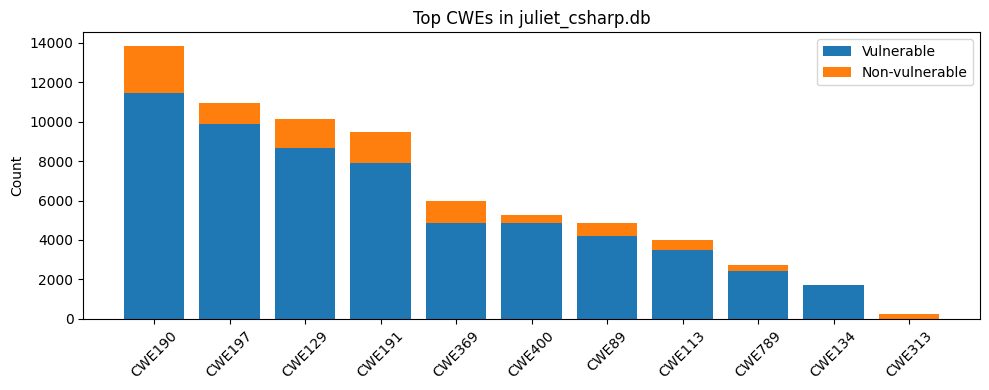

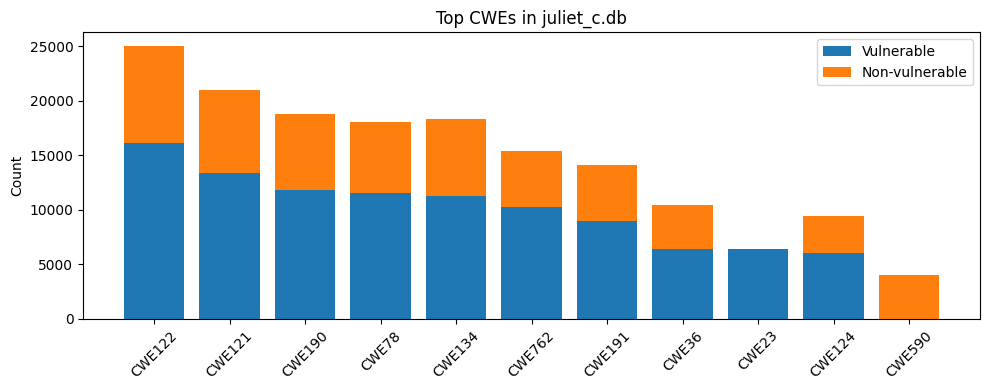

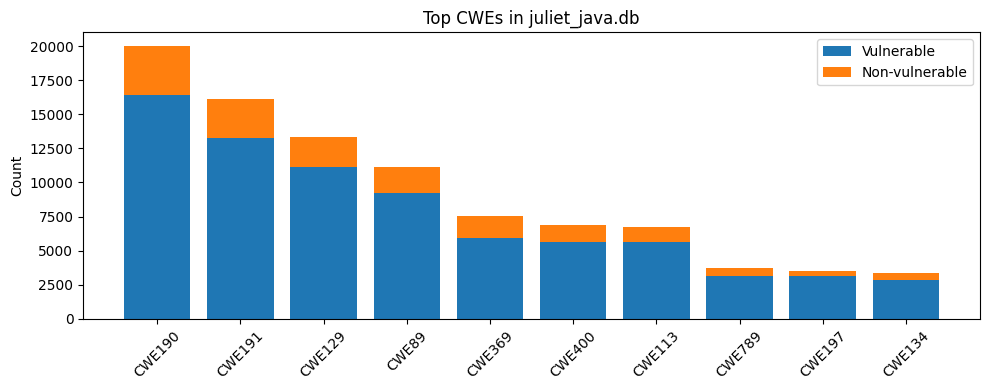

In [9]:
# Refined stats: binary for bugsinpy/devign, full CWE breakdown for Juliet DBs
juliet_cwe_stats = {}
for db_file in db_files:
    db_path = os.path.join(db_dir, db_file)
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT grp, id, start, end, vuln, len FROM funcs WHERE len BETWEEN 10 AND 150", conn)
    if db_file in ['bugsinpy.db', 'devign.db']:
        # Binary vulnerable/non-vulnerable (vuln==1 is vulnerable, vuln==0 is not)
        vuln = df['vuln'] == '1'
        vuln_count = vuln.sum()
        non_vuln_count = (~vuln).sum()
        print(f"{db_file}: Vulnerable={vuln_count}, Non-vulnerable={non_vuln_count}")
    elif db_file.startswith('juliet'):
        # For Juliet, show full CWE breakdown for positive and negative
        pos = df['vuln'].notnull() & (df['vuln'] != '')
        neg = ~pos
        cwe_pos = df[pos].groupby('grp').size().sort_values(ascending=False)
        cwe_neg = df[neg].groupby('grp').size().sort_values(ascending=False)
        juliet_cwe_stats[db_file] = {'positive': cwe_pos, 'negative': cwe_neg}
        print(f"{db_file} CWE breakdown:")
        print("  Positive (vulnerable):\n", cwe_pos)
        print("  Negative (non-vulnerable):\n", cwe_neg)
    conn.close()

# Optionally, plot top CWEs for each Juliet DB
for db_file, cwe_dict in juliet_cwe_stats.items():
    plt.figure(figsize=(10,4))
    cwe_pos = cwe_dict['positive'].head(10)
    cwe_neg = cwe_dict['negative'].head(10)
    plt.bar(cwe_pos.index, cwe_pos.values, label='Vulnerable')
    plt.bar(cwe_neg.index, cwe_neg.values, bottom=cwe_pos.reindex(cwe_neg.index, fill_value=0).values, label='Non-vulnerable')
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.title(f'Top CWEs in {db_file}')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# Export ordered CWE stats with ratio column for each Juliet DB to CSV
for db_file, cwe_dict in juliet_cwe_stats.items():
    cwe_index = cwe_dict['positive'].index.union(cwe_dict['negative'].index)
    pos_counts = cwe_dict['positive'].reindex(cwe_index, fill_value=0)
    neg_counts = cwe_dict['negative'].reindex(cwe_index, fill_value=0)
    total_counts = pos_counts + neg_counts
    ratio = neg_counts / pos_counts.replace(0, float('nan'))
    cwe_stats_df = pd.DataFrame({
        'Vulnerable': pos_counts,
        'Non_vulnerable': neg_counts,
        'Total': total_counts,
        'Neg_to_Pos_Ratio': ratio
    })
    cwe_stats_df = cwe_stats_df.sort_values('Total', ascending=False)
    csv_name = f"{db_file.replace('.db','')}_cwe_stats.csv"
    cwe_stats_df.to_csv(csv_name)
    print(f"Saved ordered CWE stats for {db_file} to {csv_name}")

Saved ordered CWE stats for juliet_csharp.db to juliet_csharp_cwe_stats.csv
Saved ordered CWE stats for juliet_c.db to juliet_c_cwe_stats.csv
Saved ordered CWE stats for juliet_java.db to juliet_java_cwe_stats.csv
